# Empirical Finance - 20999

# Lab 5: Multivariate problems in probability and statistics

### A brief recap of linear algebra operations with NumPy


As is well known, `NumPy` is the core Python package for numerical computing.
It provides powerful tools for handling vectors and multidimensional arrays (stored as `ndarray` objects) and for performing standard linear algebra operations.

In particular, the `numpy.linalg` module includes the most relevant linear algebra routines we are likely to need.

Let us first review a few fundamental commands and functions available for `NumPy` objects.


In [1]:
import numpy as np

In [2]:
b = np.array([2, 0, -1, 1])
b

array([ 2,  0, -1,  1])

In [3]:
b.shape

(4,)

In [4]:
b[1]

np.int64(0)

Given a single vector $\mathbf{b} \in \mathbb{R}^n$, one of the most fundamental operations we can perform is the computation of its (Euclidean) norm, defined as
$$ \| \mathbf{b} \| = \sqrt{ \sum_{i=1}^n b_i^2 }. $$
Equivalently, the norm can be expressed in matrix form as
$$ \| \mathbf{b} \| = \sqrt{ \mathbf{b}'\mathbf{b} }, $$
so that
$$ \|\mathbf{b}\|^2 = \mathbf{b}' \mathbf{b}. $$

In [5]:
np.linalg.norm(b)

np.float64(2.449489742783178)

In [6]:
np.sqrt(np.dot(b.T, b))

np.float64(2.449489742783178)

In [7]:
np.sqrt(np.dot(b, b))

np.float64(2.449489742783178)

In [8]:
b.T

array([ 2,  0, -1,  1])

In [9]:
b

array([ 2,  0, -1,  1])

In [10]:
np.sqrt(b @ b)

np.float64(2.449489742783178)

In `NumPy`, one-dimensional arrays are not strictly interpreted as row or column vectors.

Consequently, the transpose operation has no effect on them, and the command `np.dot(a, b)` correctly computes their scalar (inner) product.

If, instead, a vector `b2` is declared as a two-dimensional `NumPy` array, it is explicitly stored as a column vector of shape $(n,1)$. In this case, the transpose operator becomes meaningful and returns an array of shape $(1,n)$, that is, a row vector.

Accordingly, the product `np.dot(b2.T, b2)` produces a $(1,1)$ array, which is the two-dimensional analogue of the scalar inner product. In contrast, the product `np.dot(b2, b2)` is no longer defined, since the inner dimensions of the two arrays do not match.


In [11]:
b2 = np.array( [[2],[0],[-1],[1]] )
b2

array([[ 2],
       [ 0],
       [-1],
       [ 1]])

In [12]:
b

array([ 2,  0, -1,  1])

In [13]:
b2.shape

(4, 1)

In [14]:
b.shape

(4,)

In [15]:
b2.T

array([[ 2,  0, -1,  1]])

In [16]:
b2.T.shape

(1, 4)

In [17]:
np.sqrt(b @ b)

np.float64(2.449489742783178)

In [18]:
np.sqrt(np.dot(b2.T, b2))[0][0]

np.float64(2.449489742783178)

Matrices are defined as two-dimensional arrays, and the `np.dot` function can still be used to compute their products following the standard rules of linear algebra.  

When multiplying one-dimensional and two-dimensional arrays, `np.dot` automatically interprets the operation in the only mathematically consistent way: the one-dimensional array is treated as either a row or a column vector, depending on its position in the product.  

In [19]:
A = np.array([[3, 0, -2],[1, 4, -1],[2, 3, 0],[-1, 0, 1]])
A

array([[ 3,  0, -2],
       [ 1,  4, -1],
       [ 2,  3,  0],
       [-1,  0,  1]])

In [20]:
A.shape

(4, 3)

In [21]:
A[2,1]

np.int64(3)

In [22]:
A.T

array([[ 3,  1,  2, -1],
       [ 0,  4,  3,  0],
       [-2, -1,  0,  1]])

In [23]:
A

array([[ 3,  0, -2],
       [ 1,  4, -1],
       [ 2,  3,  0],
       [-1,  0,  1]])

In [24]:
b

array([ 2,  0, -1,  1])

In [25]:
np.dot(b.T, A)

array([ 3, -3, -3])

In [26]:
b @ A

array([ 3, -3, -3])

In [27]:
c = np.array([1, 0, -1])
c

array([ 1,  0, -1])

In [28]:
np.dot(b.T, A, c)

array([ 3, -3, -3])

In [29]:
np.dot(np.dot(b, A), c)

np.int64(27)

In [30]:
b @ A @ c

np.int64(27)

Regarding stacking operations between a matrix and a vector, the "vertical case" (when you need to add a new row to a matrix) is straightforward: the vector must simply have the same number of columns as the matrix, and `np.vstack` can be used directly.

"Horizontal stacking" (namely, adding a new column to the matrix), on the other hand, requires a bit more care, since the vector must be reshaped into a two-dimensional column array (for instance, using `reshape(-1, 1)`) so that its number of rows matches that of the matrix.

In [31]:
A

array([[ 3,  0, -2],
       [ 1,  4, -1],
       [ 2,  3,  0],
       [-1,  0,  1]])

In [32]:
c

array([ 3, -3, -3])

In [33]:
np.vstack([A, c])

array([[ 3,  0, -2],
       [ 1,  4, -1],
       [ 2,  3,  0],
       [-1,  0,  1],
       [ 3, -3, -3]])

In [34]:
b

array([ 2,  0, -1,  1])

In [35]:
b2

array([[ 2],
       [ 0],
       [-1],
       [ 1]])

In [36]:
np.hstack([A, b2])

array([[ 3,  0, -2,  2],
       [ 1,  4, -1,  0],
       [ 2,  3,  0, -1],
       [-1,  0,  1,  1]])

In [37]:
b.reshape(-1,1)

array([[ 2],
       [ 0],
       [-1],
       [ 1]])

In [38]:
D = np.hstack([A, b.reshape(-1,1)])
D

array([[ 3,  0, -2,  2],
       [ 1,  4, -1,  0],
       [ 2,  3,  0, -1],
       [-1,  0,  1,  1]])

Finally, standard operators for square matrices, such as the determinant, the inverse and the rank (the latter also being available for rectangular matrices), are provided within the `numpy.linalg` module.

In [39]:
np.linalg.det(D)

np.float64(38.99999999999999)

In [40]:
np.linalg.matrix_rank(D)

np.int64(4)

In [41]:
invD = np.linalg.inv(D)
invD

array([[ 0.17948718, -0.30769231,  0.41025641,  0.05128205],
       [-0.05128205,  0.23076923,  0.02564103,  0.12820513],
       [-0.02564103, -0.38461538,  0.51282051,  0.56410256],
       [ 0.20512821,  0.07692308, -0.1025641 ,  0.48717949]])

In [42]:
invD @ D

array([[ 1.00000000e+00, -1.11022302e-16,  0.00000000e+00,
         1.11022302e-16],
       [ 2.77555756e-17,  1.00000000e+00,  0.00000000e+00,
        -2.77555756e-17],
       [ 0.00000000e+00,  1.11022302e-16,  1.00000000e+00,
        -1.11022302e-16],
       [ 0.00000000e+00,  4.16333634e-17,  0.00000000e+00,
         1.00000000e+00]])

### On the solutions of generic linear systems

Consider the generic linear system
$$\mathbf{Ax} = \mathbf{b}$$
with the matrix of the coefficients $\mathbf{A} \in \mathbb{R}^{n \times k}$, the vector of unknowns $\mathbf{x} \in \mathbb{R}^k$ and the vector of constants $\mathbf{b} \in \mathbb{R}^n$.

Thanks to the Rouché-Capelli Theorem, it is known that this linear system is solvable if and only if
$$ \mathrm{rk} \left[ \mathbf{A} \right] = \mathrm{rk} \left[ \mathbf{A} | \mathbf{b} \right] $$
where, $\mathbf{A} | \mathbf{b} \in \mathbb{R}^{n \times (k+1)}$ is the so-called augment matrix, obtained by appending the column vector of constants $\mathbf{b}$ to $\mathbf{A}$.

If $n = k$, the linear system is referred to as a *square* linear system which, if it is solvable, admits one and only one solution,
$$ \mathbf{x}^* = \mathbf{A}^{-1} \mathbf{b}. $$

In [43]:
A = np.array([[ 3,  0, -2,  2],
       [ 1,  4, -1,  0],
       [ 2,  3,  0, -1],
       [-1,  0,  1,  1]])

b = np.array([13,
              2,
              -2,
              2])

In [44]:
Ab = np.hstack([A, b.reshape(-1,1)])
Ab

array([[ 3,  0, -2,  2, 13],
       [ 1,  4, -1,  0,  2],
       [ 2,  3,  0, -1, -2],
       [-1,  0,  1,  1,  2]])

In [45]:
np.linalg.matrix_rank(A) == np.linalg.matrix_rank(Ab)

np.True_

In [46]:
invA = np.linalg.inv(A)
xstar = invA @ b
xstar

array([ 1.00000000e+00, -1.11022302e-16, -1.00000000e+00,  4.00000000e+00])

In [47]:
# xstar = [1, 0, -1, 4]

In [48]:
xstar = np.linalg.solve(A, b)
xstar

array([ 1.00000000e+00,  4.16333634e-17, -1.00000000e+00,  4.00000000e+00])

If $\mathbf{x}^*$ is an exact solution of the system, then
$$
\mathbf{A}\mathbf{x}^* - \mathbf{b} = \mathbf{0},
$$
and, consequently,
$$
\|\mathbf{A}\mathbf{x}^* - \mathbf{b}\|^2 = 0.
$$

In [49]:
A @ xstar - b

array([0., 0., 0., 0.])

In [50]:
(A @ xstar - b) @ (A @ xstar - b)

np.float64(0.0)

Any other vector $\tilde{\mathbf{x}}$ that is not an exact solution of the linear system will satisfy
$$
\mathbf{A}\tilde{\mathbf{x}} - \mathbf{b} \neq \mathbf{0},
$$
and therefore
$$
\|\mathbf{A}\tilde{\mathbf{x}} - \mathbf{b}\|^2 > 0.
$$
The quantity $\|\mathbf{A}\tilde{\mathbf{x}} - \mathbf{b}\|^2$ can be interpreted as a measure of the residual error associated with the candidate solution $\tilde{\mathbf{x}}$. In particular, if $\tilde{\mathbf{x}}$ is "close" to $\mathbf{x}^*$, the corresponding squared norm will be small, whereas if $\tilde{\mathbf{x}}$ is "far" from $\mathbf{x}^*$, the squared norm will be large.

(Note: one way to measure the (Euclidean) distance between two vectors is to compute the (Euclidean) norm of their difference.)

In [51]:
# xstar = [1, 0, -1, 4]

xtilde = np.array([0.5, 0, -0.5, 3.5])

np.linalg.norm(xtilde -xstar)

np.float64(0.8660254037844386)

In [52]:
(A @ xtilde -b) @ (A @ xtilde -b)

np.float64(13.75)

In [53]:
xtilde = np.array([3, 0, 3, 7])

np.linalg.norm(xtilde -xstar)

np.float64(5.385164807134504)

In [54]:
(A @ xtilde -b) @ (A @ xtilde -b)

np.int64(46)

### On overdetermined linear systems

This is why, in the case of a linear system with many more linearly independent equations than unknowns (that is, when $n \gg k$), which is referred to as an `overdetermined` linear system, we define the approximate solution as
$$
\mathbf{x}^* = \arg \min_{\mathbf{x} \in \mathbb{R}^k} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|^2.
$$
Assuming that $\mathbf{A}$ has full column rank, that is, $\mathrm{rk}[\mathbf{A}] = k$, we obtain
$$
\mathbf{x}^* = (\mathbf{A}' \mathbf{A})^{-1}\mathbf{A}' \mathbf{b}.
$$

In [55]:
A = np.array([[ 3,  0],
       [ 1,  4],
       [ 2,  3],
       [-1,  0]])

b = np.array([13,
              2,
              -2,
              2])

In [56]:
Ab = np.hstack([A, b.reshape(-1,1)])
np.linalg.matrix_rank(A) == np.linalg.matrix_rank(Ab)

np.False_

In [57]:
np.linalg.matrix_rank(A) == A.shape[1]

np.True_

In [58]:
xstar = np.linalg.inv( A.T @ A ) @ A.T @ b
xstar

array([ 3.10909091, -1.16363636])

Alternatively, we can also rely on a numerical optimization routine, such as the `minimize` function from the `scipy.optimize` module.  
In its most basic usage, this function requires only the definition of the objective function (which will be minimized with respect to its first argument) and a numerical initial guess for the parameters.

In [59]:
from scipy.optimize import minimize

def objFct(x, A, b):
  return np.linalg.norm(A @ x -b)**2

x0 = np.zeros(A.shape[1])

res = minimize(objFct, x0, args = (A,b))

In [60]:
type(res)

scipy.optimize._optimize.OptimizeResult

In [61]:
res.x

array([ 3.10909086, -1.16363635])

In [62]:
res.fun

np.float64(74.50909090909092)

As discussed in Examples 5.14 and 5.15 of the Lecture Notes, the problem of an overdetermined system has a clear geometric interpretation when $k = 2$ and the first column of $\mathbf{A}$ consists of ones.

Consider, for example, the following matrix of coefficients, vector of unknowns, and vector of constants (all from Example 5.14):
$$
\mathbf{A} =
\begin{bmatrix}
1 & 2 \\
1 & -3 \\
1 & 1 \\
1 & 0
\end{bmatrix} \in \mathbb{R}^{4 \times 2},
\qquad
\mathbf{x} =
\begin{bmatrix}
q \\
m
\end{bmatrix} \in \mathbb{R}^{2 \times 1},
\qquad
\mathbf{b} =
\begin{bmatrix}
3 \\
-1 \\
0 \\
3
\end{bmatrix} \in \mathbb{R}^{4 \times 1}.
$$

The associated explicit linear system is
$$
\begin{cases}
q + 2m = 3, \\
q - 3m = -1, \\
q + m = 0, \\
q + 0 \cdot m = 3,
\end{cases}
$$
which is clearly inconsistent, since from the last two equations we obtain $q^* = 3$ and $m^* = -q^* = -3$, values that are not compatible with the first two equations.

Nevertheless, the entries of the second column of $\mathbf{A}$ and of the vector $\mathbf{b}$ can be interpreted, respectively, as the $x$- and $y$-coordinates of the following four points in the Cartesian plane:
$$
(2, 3), \quad (-3, -1), \quad (1, 0), \quad (0, 3).
$$

In [63]:
A = np.array([[1, 2],[1, -3],[1, 1],[1, 0]])
b = np.array([3, -1, 0, 3])

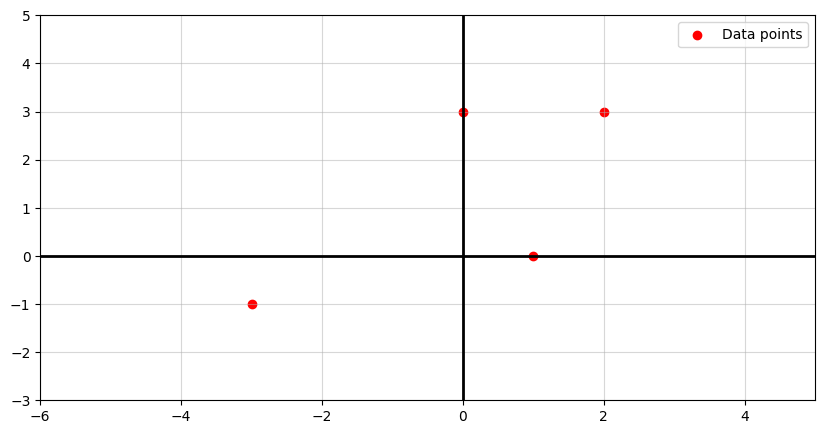

In [64]:
x_points = A[:,1]
y_points = b

import matplotlib.pyplot as plt

xlim = [-6, 5]
ylim = [-3, 5]

plt.figure(figsize=(10,5))
plt.grid(alpha = 0.5)
plt.scatter(x_points, y_points, color = 'r', label = 'Data points')
plt.axhline(0, color='black', linewidth=2)
plt.axvline(0, color='black', linewidth=2)

plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()


In this setting, the unknowns $m$ and $q$ represent the parameters of a straight line in the Cartesian plane of the form
$$
y = q + m x,
$$
where $m$ is the slope and $q$ is the intercept at the origin.  

Geometrically, the linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$ requires finding values of $m$ and $q$ such that the corresponding line $y = q + m x$ passes exactly through all four points listed above.

In [65]:
from ipywidgets import interact

def Dynamic_RegressionLine(m = 1, q = 0):
    plt.figure(figsize=(10, 5))
    plt.scatter(x_points, y_points, color = 'r', label = 'Data points')
    plt.axhline(0, color='black', linewidth=2)
    plt.axvline(0, color='black', linewidth=2)

    xlim = [-6, 5]
    ylim = [-3, 5]

    x_line = np.linspace(xlim[0], xlim[1], 100)
    y_line = m*x_line +q
    plt.plot(x_line, y_line, 'b-', label=f'Regression line: y = {m:.2f}x + {q:.2f}')

    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.legend()
    plt.grid()
    plt.show()

interact(Dynamic_RegressionLine, m=(-2.0, 4.0, 0.05), q=(-5.0, 5.0, 0.05));

interactive(children=(FloatSlider(value=1.0, description='m', max=4.0, min=-2.0, step=0.05), FloatSlider(value…

However, since the system is overdetermined, no single line can pass through all of them simultaneously.  

The best we can do, therefore, is to find the line that \emph{approximately} fits the points in the least-squares sense, that is, the one that minimizes the sum of the squared vertical distances between the points and the line, solving
$$
\mathbf{x}^* = \arg \min_{\mathbf{x} \in \mathbb{R}^k} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|^2.
$$

In [66]:
from ipywidgets import interact

def Dynamic_RSSMinimization(m = 1, q = 0):
    plt.figure(figsize=(10, 5))
    plt.scatter(x_points, y_points, color = 'r', label = 'Data points')
    plt.axhline(0, color='black', linewidth=2)
    plt.axvline(0, color='black', linewidth=2)

    xlim = [-6, 5]
    ylim = [-3, 5]

    x_line = np.linspace(xlim[0], xlim[1], 100)
    y_line = m*x_line +q
    plt.plot(x_line, y_line, 'b-', label=f'Regression line: y = {m:.2f}x + {q:.2f}')

    y_hat = m * x_points + q
    residuals = y_hat - y_points

    plt.scatter(x_points, y_hat, color = 'g', label = 'Fitted values')
    for i in range(len(x_points)):
      plt.plot([x_points[i], x_points[i]], [y_points[i], y_hat[i]], linestyle = '--', color = 'm')

    plt.plot([], [], linestyle='--', color='m', label='Residuals')

    RSS = residuals @ residuals

    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title(f'Objective function= {RSS:.2f}')
    plt.legend()
    plt.grid()
    plt.show()

interact(Dynamic_RSSMinimization, m=(-2.0, 4.0, 0.05), q=(-5.0, 5.0, 0.05));

interactive(children=(FloatSlider(value=1.0, description='m', max=4.0, min=-2.0, step=0.05), FloatSlider(value…

The solution is the one identified above:
$$
\mathbf{x}^* = \left[ \begin{array}{c} q^* \\ m^* \end{array} \right] =  (\mathbf{A}' \mathbf{A})^{-1}\mathbf{A}' \mathbf{b}.
$$

In [67]:
xstar = np.linalg.inv(A.T @ A) @ A.T @ b
xstar

array([1.25      , 0.64285714])

Interestingly, in this setting, there exist simpler formulas for computing the optimal slope $m^*$ and the optimal intercept at the origin $q^*$, which do not require evaluating the full matrix expression for $\mathbf{x}^*$.

Indeed, from Example 5.15 of the Lecture Notes, we have
\begin{align*}
    m^* &= \frac{\hat{\mathrm{Cov}}\!\left[\mathbf{a},\, \mathbf{b}\right]}{\hat{\mathrm{V}}\!\left[\mathbf{a}\right]}, \\
    q^* &= \bar{\mathbf{b}} - m^* \bar{\mathbf{a}},
\end{align*}
where $\mathbf{a}$ denotes the second (non-constant) column of $\mathbf{A}$, and the empirical operators are defined as follows:
\begin{align*}
    \bar{\mathbf{a}} &= \frac{1}{n} \sum_{i=1}^n a_i = \frac{\mathbf{1}_n' \mathbf{a}}{n}, \\
    \bar{\mathbf{b}} &= \frac{1}{n} \sum_{i=1}^n b_i = \frac{\mathbf{1}_n' \mathbf{b}}{n}, \\
    \hat{\mathrm{V}}\!\left[\mathbf{a}\right] &= \frac{1}{n} \sum_{i=1}^n \left(a_i - \bar{\mathbf{a}}\right)^2 = \frac{\mathbf{a}' \mathbf{a} - n\,\bar{\mathbf{a}}^2}{n}, \\
    \hat{\mathrm{Cov}}\!\left[\mathbf{a},\, \mathbf{b}\right] &= \frac{1}{n} \sum_{i=1}^n \left(a_i - \bar{\mathbf{a}}\right)\left(b_i - \bar{\mathbf{b}}\right)
    = \frac{\mathbf{a}' \mathbf{b} - n\,\bar{\mathbf{a}}\bar{\mathbf{b}}}{n}.
\end{align*}

In [68]:
a = A[:, 1]
a

array([ 2, -3,  1,  0])

In [69]:
b

array([ 3, -1,  0,  3])

In [70]:
n = A.shape[0]
mstar = (a @ b - n*a.mean()*b.mean()) / (a @ a -n*a.mean()**2)
mstar

np.float64(0.6428571428571429)

In [71]:
qstar = b.mean() -mstar*a.mean()
qstar

np.float64(1.25)

A closely related problem (which can actually be seen as a constrained version of the one just analyzed) is the case in which the regression line is forced to pass through the origin, that is, where the intercept $q = 0$ is fixed to zero.

This situation is discussed in Example 5.16 of the Lecture Notes, from which the following numerical example is taken.

Consider:
$$
\mathbf{a} =
\begin{bmatrix}
2 \\
-3 \\
1 \\
-1
\end{bmatrix} \in \mathbb{R}^{4 \times 1},
\qquad
\mathbf{x} = \alpha \in \mathbb{R},
\qquad
\mathbf{b} =
\begin{bmatrix}
3 \\
-1 \\
0 \\
3
\end{bmatrix} \in \mathbb{R}^{4 \times 1}.
$$

The resulting linear system consists of $n = 4$ equations in $k = 1$ unknown and can be written as
$$
\begin{cases}
2\alpha = 3, \\
-3\alpha = -1, \\
\alpha = 0, \\
-\alpha = 3,
\end{cases}
$$
which is clearly overdetermined.

In this case, the approximate solution of the linear system can be easily computed as
$$
\alpha^* = (\mathbf{a}' \mathbf{a})^{-1} \mathbf{a}' \mathbf{b}
= \frac{\mathbf{a}' \mathbf{b}}{\mathbf{a}' \mathbf{a}}
= \frac{\sum_{i=1}^n a_i b_i}{\sum_{i=1}^n a_i^2}.
$$

In [72]:
a = np.array([2, -3, 1, -1])
b = np.array([3, -1, 0, 3])

In [73]:
alphastar = (a @ b)/(a @ a)
alphastar

np.float64(0.4)

### On the simple regression model

As discussed in Example 6.8 of the Lecture Notes, these extremely useful formulas can be expressed within the substantially equivalent, yet conceptually different, framework of the so-called **simple regression model**, in which the dependent (or target) variable $Y$ is regressed on an intercept and a single regressor (or independent variable, or feature) $X$.

The underlying regression function is given by
$$
\text{E}\!\left[ Y \,\middle|\, [1, X]' \right] = \beta_0 + \beta_1 X,
$$
while the corresponding statistical model can be written as
$$
\mathbf{y} = \beta_0 \mathbf{1}_n + \beta_1 \mathbf{x} + \boldsymbol{\varepsilon}.
$$

From a purely algebraic point of view, the ordinary least squares (OLS) estimator $\hat{\boldsymbol{\beta}}_{OLS}$ is defined as the solution to the overdetermined linear system with coefficient matrix $\mathbf{X} = [\,\mathbf{1}_n,\, \mathbf{x}\,]$ and constant vector $\mathbf{y}$, namely
$$
\hat{\boldsymbol{\beta}}_{OLS} =
\underset{\boldsymbol{\beta} \in \mathbb{R}^k}{\arg\min}\,
\|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|^2
= (\mathbf{X}' \mathbf{X})^{-1}\mathbf{X}' \mathbf{y}.
$$

For the simple regression model, this yields
\begin{align*}
    \hat{\beta}_{OLS,0} &= \bar{\mathbf{y}} - \hat{\beta}_{OLS,1}\,\bar{\mathbf{x}}, \\
    \hat{\beta}_{OLS,1} &= \frac{\hat{\mathrm{Cov}}\!\left[\mathbf{x},\,\mathbf{y}\right]}{\hat{\mathrm{V}}\!\left[\mathbf{x}\right]}.
\end{align*}

In [74]:
x = np.array([0.32, 0.31, 0.13, 0.78, 0.55, 0.36, 0.19, 0.40, 0.83, 0.53])
y = np.array([3.45, 3.14, 2.35, 3.44, 4.66, 3.32, 1.75, 3.87, 4.47, 2.25])

In [75]:
n = len(x)
n

10

In [76]:
X = np.vstack([np.ones(n), x]).T
X

array([[1.  , 0.32],
       [1.  , 0.31],
       [1.  , 0.13],
       [1.  , 0.78],
       [1.  , 0.55],
       [1.  , 0.36],
       [1.  , 0.19],
       [1.  , 0.4 ],
       [1.  , 0.83],
       [1.  , 0.53]])

In [77]:
betaOLS = np.linalg.inv(X.T @ X) @ X.T @ y
betaOLS

array([2.16556196, 2.51008646])

In [78]:
np.cov(x, y)

array([[0.05397778, 0.13548889],
       [0.13548889, 0.89      ]])

In [79]:
betaOLS1 = np.cov(x,y)[0,1]/np.cov(x,y)[0, 0]
betaOLS1

np.float64(2.510086455331411)

In [80]:
betaOLS0 = y.mean() -betaOLS1*x.mean()
betaOLS0

np.float64(2.1655619596541795)

Moreover, as shown in Example 6.24 of the Lecture Notes, the $R^2$ coefficient, which according to Proposition 6.23 can be computed as
$$
R^2 = \left( \hat{\mathrm{corr}}\!\left[\mathbf{y},\, \hat{\mathbf{y}}\right] \right)^2,
$$
where $\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}}_{OLS}$ denotes the vector of OLS-fitted values, and
$$
\hat{\mathrm{corr}}\!\left[\mathbf{x},\, \mathbf{y}\right]
= \frac{\hat{\mathrm{Cov}}\!\left[\mathbf{x},\, \mathbf{y}\right]}
{\sqrt{\widehat{\mathrm{V}}\!\left[\mathbf{x}\right]\, \widehat{\mathrm{V}}\!\left[\mathbf{y}\right]}},
$$
can, in the case of the simple regression model, be equivalently expressed as
$$
R^2 = \left( \hat{\mathrm{corr}}\!\left[\mathbf{x},\, \mathbf{y}\right] \right)^2.
$$

In [81]:
yhat = X @ betaOLS
yhat

array([2.96878963, 2.94368876, 2.4918732 , 4.12342939, 3.54610951,
       3.06919308, 2.64247839, 3.16959654, 4.24893372, 3.49590778])

In [82]:
R2 = np.corrcoef(y, yhat)[0,1]**2
R2

np.float64(0.38212227511000285)

In [83]:
np.corrcoef(y, x)[0,1]**2

np.float64(0.3821222751100026)

If the model features no intercept, that is, if the regression function is simply
$$
\text{E}\!\left[ Y \,\middle|\, X \right] = \beta X,
$$
and the corresponding statistical model is
$$
\mathbf{y} = \beta \mathbf{x} + \boldsymbol{\varepsilon},
$$
then
$$
\hat{\beta}_{OLS} = (\mathbf{x}' \mathbf{x})^{-1} \mathbf{x}' \mathbf{y}
= \frac{\mathbf{x}' \mathbf{y}}{\mathbf{x}' \mathbf{x}}
= \frac{\sum_{i=1}^n x_i y_i}{\sum_{i=1}^n x_i^2}.
$$

Since there is no intercept, the $R^2$ coefficient can still be computed numerically; however, it has no meaningful interpretation in this context.

## BONUS 1: A 3D plot of the objective function

To gain further insight into the nature of the least-squares approximation, it is useful to visualize the behavior of the objective function associated with the overdetermined linear system analyzed above.  
Recall that, in this special case, the coefficient matrix $\mathbf{A}$ and the vector of constants $\mathbf{b}$ are given by
$$
\mathbf{A} =
\begin{bmatrix}
1 & 2 \\
1 & -3 \\
1 & 1 \\
1 & 0
\end{bmatrix},
\qquad
\mathbf{b} =
\begin{bmatrix}
3 \\
-1 \\
0 \\
3
\end{bmatrix},
$$
and that we seek the approximate solution
$$
\mathbf{x}^* =
\begin{bmatrix}
q^* \\
m^*
\end{bmatrix}
= \underset{\mathbf{x} \in \mathbb{R}^2}{\arg\min} \, \|\mathbf{A}\mathbf{x} - \mathbf{b}\|^2.
$$

The corresponding objective function
$$
f(q, m) = \|\mathbf{A}\mathbf{x} - \mathbf{b}\|^2,
\qquad
\text{with } \mathbf{x} = [q,\, m]',
$$
represents the squared norm of the residual vector as a function of the parameters $q$ (intercept) and $m$ (slope).  

In the following three-dimensional dynamic plot, $f(q,m)$ is displayed as a continuous surface over a region of the $(q,m)$-plane.  
The global minimum of the surface, highlighted in red, corresponds to the optimal least-squares solution $\mathbf{x}^* = [q^*,\, m^*]'$ that minimizes the squared residuals and hence defines the line that best fits the given data in the least-squares sense.

In [84]:
import plotly.graph_objects as go

A = np.array([[1, 2],
              [1, -3],
              [1, 1],
              [1, 0]])
b = np.array([3, -1, 0, 3])

x_star = np.linalg.inv(A.T @ A) @ (A.T @ b)
q_star, m_star = x_star

def f(q, m):
    x = np.stack([q, m], axis=-1)
    Ax = np.einsum('ij,...j->...i', A, x)
    r = Ax - b
    return np.sum(r**2, axis=-1)

q_vals = np.linspace(q_star - 5, q_star + 5, 100)
m_vals = np.linspace(m_star - 5, m_star + 5, 100)
Q, M = np.meshgrid(q_vals, m_vals)
Z = f(Q, M)

fig = go.Figure(data=[
    go.Surface(x=Q, y=M, z=Z, colorscale='Viridis', opacity=0.8),
    go.Scatter3d(x=[q_star], y=[m_star], z=[f(q_star, m_star)],
                 mode='markers', marker=dict(size=6, color='red'),
                 name='Global minimum')
])

fig.update_layout(
    scene=dict(
        xaxis_title='q',
        yaxis_title='m',
        zaxis_title='||A x - b||²'
    )
)

fig.show()


## BONUS 2: Fitting a few points in the 3D space

As a natural extension of the previous discussion on overdetermined linear systems and their least-squares solutions, we now consider a slightly more complex case in which the goal is to fit a set of points in three-dimensional space.

Starting from the same system analyzed earlier, we now enrich the matrix of coefficients $\mathbf{A}$ by adding a third column,
$$
\mathbf{A} =
\begin{bmatrix}
1 & 2 & 1 \\
1 & -3 & 0 \\
1 & 1 & 2 \\
1 & 0 & 5
\end{bmatrix} \in \mathbb{R}^{4 \times 3},
\qquad
\mathbf{b} =
\begin{bmatrix}
3 \\
-1 \\
0 \\
3
\end{bmatrix} \in \mathbb{R}^{4 \times 1}.
$$

In this formulation, each row of $\mathbf{A}$ corresponds to the coordinates $(x_i, y_i)$ of a point in the plane, while the corresponding element $b_i$ represents the observed value of $z_i$.

These four points, displayed below, are:
$$
(2,\, 1,\, 3), \quad (-3,\, 0,\, -1), \quad (1,\, 2,\, 0), \quad (0,\, 5,\, 3).
$$

In [85]:
A = np.array([[1, 2, 1],
              [1, -3, 0],
              [1, 1, 2],
              [1, 0, 5]])
b = np.array([3, -1, 0, 3])

x = A[:, 1]
y = A[:, 2]
z = b

fig = go.Figure()

fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='markers',
                           marker=dict(size=6, color='red'),
                           name='Data points'))

fig.update_layout(
    scene=dict(xaxis_title='x',
               yaxis_title='y',
               zaxis_title='z'),
    width=800, height=600
)
fig.show()

The system
$$
\mathbf{A}\mathbf{x} = \mathbf{b},
\qquad \text{with } \mathbf{x} =
\begin{bmatrix}
q \\ m_1 \\ m_2
\end{bmatrix},
$$
now describes a set of $n = 4$ equations in $k = 3$ unknowns, that reads
$$
\begin{cases}
q + 2m_1 + 1m_2 = 3, \\
q - 3m_1 + 0m_2 = -1, \\
q + 1m_1 + 2m_2 = 0, \\
q + 0 \cdot m_1 + 5m_2 = 3.
\end{cases}
$$

Since the system is again overdetermined, it admits no exact solution.  
The least-squares approach provides the best-fitting plane, defined by the coefficients
$$
\mathbf{x}^* = (\mathbf{A}'\mathbf{A})^{-1}\mathbf{A}'\mathbf{b},
$$
which minimize, as usual, the sum of squared residuals $\|\mathbf{A}\mathbf{x} - \mathbf{b}\|^2$.  

In the following interactive three-dimensional plot, the previous four data points are displayed together with the fitted plane
$$
z = q^* + m_1^* x + m_2^* y,
$$
which provides the least-squares approximation of the observed data.


In [86]:
xstar = np.linalg.inv(A.T @ A) @ A.T @ b
q_hat, m1_hat, m2_hat = xstar

x_lin = np.linspace(x.min() - 1, x.max() + 1, 20)
y_lin = np.linspace(y.min() - 1, y.max() + 1, 20)
Xg, Yg = np.meshgrid(x_lin, y_lin)
Zg = q_hat + m1_hat * Xg + m2_hat * Yg

fig = go.Figure()

fig.add_trace(go.Surface(x=Xg, y=Yg, z=Zg, colorscale='Viridis', opacity=0.75,
                         name='Fitted plane'))
fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='markers',
                           marker=dict(size=6, color='red'),
                           name='Data points'))

fig.update_layout(
    scene=dict(xaxis_title='x',
               yaxis_title='y',
               zaxis_title='z'),
    width=800, height=600
)
fig.show()

BEWARE: In this case (that is, in a linear regression model with more than one proper regressor) the estimates of the individual "slope" coefficients CANNOT be computed using the simplified formula recalled earlier, which expresses the slope as the ratio between the empirical covariance and the empirical variance.

In particular, the second entry of
$$
\mathbf{x}^* =
\begin{bmatrix}
q^* \\[4pt] m_1^* \\[4pt] m_2^*
\end{bmatrix}
= (\mathbf{A}'\mathbf{A})^{-1}\mathbf{A}'\mathbf{b},
$$
does NOT coincide with
$$
\frac{\hat{\mathrm{Cov}}\!\left[\mathbf{a}_1,\, \mathbf{b}\right]}
{\hat{\mathrm{V}}\!\left[\mathbf{a}_1\right]},
$$
where $\mathbf{a}_1$ denotes the second column of $\mathbf{A}$, corresponding to the coefficient $m_1$.

In [87]:
xstar

array([0.40555556, 0.52222222, 0.42222222])

In [88]:
a1 = A[:,1]

(a1 @ b -n*a1.mean()*b.mean())/(a1 @ a1 - n*a1.mean()**2)

np.float64(0.6428571428571429)

Nevertheless, the OLS estimate of the intercept can still be computed in a manner similar to the previous case.  
Indeed, we have
$$
q^* = \bar{\mathbf{b}} - m_1^* \bar{\mathbf{a}}_1 - m_2^* \bar{\mathbf{a}}_2,
$$
(Why??? Prove this!)

In [89]:
a2 = A[:,2]

b.mean() -xstar[1]*a1.mean() -xstar[2]*a2.mean()

np.float64(0.40555555555555567)